# Notebook Guide

This notebook is the first inspection pass for the project. The goal is to understand the raw dataset before any cleaning or modeling happens.

What to focus on while reading:
- how the raw expression matrix is loaded,
- how metadata is stored separately from expression values,
- whether the matrix dimensions match expectations,
- and whether missing values or mixed data types need special handling before preprocessing.

By the end of this notebook, you should know what the raw files look like and why the next preprocessing stage is necessary.

---

## Import libraries

This cell loads the main libraries used throughout the notebook.

- `pandas` (`pd`) is used for loading and analyzing tabular gene expression and metadata files.
- `numpy` (`np`) provides numerical operations such as transformations on the expression matrix.
- `matplotlib.pyplot` (`plt`) is used to create plots.
- `seaborn` (`sns`) is imported for statistical plotting support and improved plot styling, even if it is not used yet in the next cells.
- `yaml` is used to read settings from `config.yaml`.

The `print(...)` statement is just a quick check that the imports completed successfully.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

print("All libraries imported successfully!")

All libraries imported successfully!


## Load project configuration

This cell reads the project settings from `../config.yaml` so the notebook can use the same paths and parameters defined for the rest of the project.

- `with open(..., 'r') as f:` opens the config file in read mode.
- `yaml.safe_load(f)` converts the YAML file into a Python dictionary named `config`.
- `safe_load` is preferred because it safely parses standard YAML content without executing arbitrary Python objects.

The final `print(...)` helps confirm that the configuration was loaded correctly.


In [2]:
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)
print("Config loaded:", config)


Config loaded: {'data': {'raw_expression': 'data/raw/melanoma_expression.csv', 'raw_metadata': 'data/raw/melanoma_metadata.csv', 'processed_expression': 'data/processed/expression_clean.csv', 'processed_metadata': 'data/processed/metadata_clean.csv'}, 'preprocessing': {'variance_percentile': 20, 'log_transform': True, 'scale': True, 'max_genes': 5000}, 'pca': {'n_components': 50, 'random_state': 42}, 'umap': {'n_components': 2, 'n_neighbors': 15, 'min_dist': 0.1, 'random_state': 42}, 'clustering': {'k_range_min': 2, 'k_range_max': 9, 'n_init': 10, 'random_state': 42}, 'models': {'save_dir': 'models/'}, 'results': {'save_dir': 'results/'}}


## Load the expression matrix

This cell loads the raw melanoma gene expression dataset into a DataFrame called `expr`.

- `pd.read_csv(...)` reads the CSV file into memory.
- `index_col=0` tells pandas to use the first column as the row index instead of treating it as normal data. In this dataset, that usually means gene identifiers become row labels.
- `expr.shape` returns `(rows, columns)`, which helps us verify dataset size immediately after loading.

This gives us the main matrix we will explore in the following cells.


In [5]:
print("Loading expression data...")
expr = pd.read_csv('../data/raw/melanoma_expression.csv', index_col=0)
print(f"Expression matrix shape: {expr.shape}")

Loading expression data...
Expression matrix shape: (4645, 23686)


## Inspect matrix dimensions and sample values

This cell performs a quick sanity check on the expression matrix.

- `expr.shape[0]` gives the number of rows, which here represent genes.
- `expr.shape[1]` gives the number of columns, which here represent cells or samples.
- `expr.iloc[:5, :5]` selects the first 5 rows and first 5 columns by integer position.

Using `iloc` is helpful when we want a small preview without relying on row or column names.


In [6]:
print(f"Rows (genes): {expr.shape[0]}")
print(f"Columns (cells): {expr.shape[1]}")
print("\nFirst 5 rows, first 5 columns:")
print(expr.iloc[:5, :5])

Rows (genes): 4645
Columns (cells): 23686

First 5 rows, first 5 columns:
                             C9orf152   RPS11   ELMO2  CREB3L1  PNMA1
Cy72_CD45_H02_S758_comb           0.0  9.2172  0.0000      0.0    0.0
CY58_1_CD45_B02_S974_comb         0.0  8.3745  0.0000      0.0    0.0
Cy71_CD45_D08_S524_comb           0.0  9.3130  2.1263      0.0    0.0
Cy81_FNA_CD45_B01_S301_comb       0.0  7.8876  0.0000      0.0    0.0
Cy80_II_CD45_B07_S883_comb        0.0  8.3291  0.0000      0.0    0.0


## Load metadata

This cell loads the metadata table into `meta` so we can compare sample annotations with the expression matrix.

- `pd.read_csv(...)` reads the metadata CSV.
- `index_col=0` again uses the first column as the index, which is often useful for labels such as metadata field names or sample identifiers.
- `meta.head(10)` prints the first 10 rows for a quick preview.

This helps us understand what descriptive information is available alongside the expression data.


In [7]:
meta = pd.read_csv('../data/raw/melanoma_metadata.csv', index_col=0)
print(f"Metadata shape: {meta.shape}")
print(meta.head(10))

Metadata shape: (4645, 3)
                              tumor  malignant(1=no,2=yes,0=unresolved)  \
Cy72_CD45_H02_S758_comb        72.0                                 1.0   
CY58_1_CD45_B02_S974_comb      58.0                                 1.0   
Cy71_CD45_D08_S524_comb        71.0                                 2.0   
Cy81_FNA_CD45_B01_S301_comb    81.0                                 2.0   
Cy80_II_CD45_B07_S883_comb     80.0                                 2.0   
Cy81_Bulk_CD45_B10_S118_comb   81.0                                 2.0   
Cy72_CD45_D09_S717_comb        72.0                                 1.0   
Cy74_CD45_A03_S387_comb        74.0                                 1.0   
Cy71_CD45_B05_S497_comb        71.0                                 2.0   
Cy80_II_CD45_C09_S897_comb     80.0                                 2.0   

                              non-malignant cell type (1=T,2=B,3=Macro.4=Endo.,5=CAF;6=NK)  
Cy72_CD45_H02_S758_comb                                

## Check expression data types

This cell checks the data types stored in the expression matrix.

- `expr.dtypes` returns the dtype of each column.
- `value_counts()` summarizes how many columns use each dtype.

This is useful for confirming that the expression values were loaded as numeric types rather than strings or mixed objects.


In [8]:
print("Data types:")
print(expr.dtypes.value_counts())


Data types:
float64    23686
Name: count, dtype: int64


## Check missing values per column

This cell looks for missing values in the expression matrix.

- `expr.isnull()` creates a boolean DataFrame where `True` marks missing entries.
- `.sum()` on that boolean result counts missing values column by column.
- The result is stored in `missing`.

This version gives a per-column summary, which is useful if we want to identify where missingness is concentrated.


In [9]:
missing = expr.isnull().sum()
print(f"Total missing values: {missing}")


Total missing values: C9orf152    0
RPS11       0
ELMO2       0
CREB3L1     0
PNMA1       0
           ..
PIK3IP1     0
SNRPD2      0
SLC39A6     0
CTSC        0
AQP7        0
Length: 23686, dtype: int64


## Check total missing values

This cell computes the total number of missing values across the entire expression matrix.

- `expr.isnull().sum().sum()` applies two sums:
- The first `.sum()` adds missing counts within each column.
- The second `.sum()` adds those column totals into one overall number.

This gives a single quality-control value for the whole dataset.


In [10]:
missing = expr.isnull().sum().sum()
print(f"Total missing values: {missing}")


Total missing values: 0


## Summarize all expression values together

This cell computes descriptive statistics over all expression values combined.

- `expr.stack()` reshapes the DataFrame into a single Series by stacking all columns into one long vector.
- `.describe()` then calculates summary statistics such as count, mean, standard deviation, minimum, quartiles, and maximum.

This is useful when we want a global view of the expression value distribution instead of per-gene or per-sample summaries.


In [11]:
print("Expression value statistics:")
print(expr.stack().describe())

Expression value statistics:
count    1.100215e+08
mean     4.644466e-01
std      1.300944e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.592300e+01
dtype: float64


## Summarize expression values by column

This cell calculates descriptive statistics for each column of the expression matrix.

- `expr.describe()` returns summary statistics for every numeric column separately.
- This helps compare ranges, means, and spread across cells or samples.

Compared with the previous cell, this view keeps each column separate instead of combining all values into one distribution.


In [12]:
# Cell 7: Basic statistics
print("Expression value statistics:")
print(expr.describe())

Expression value statistics:
          C9orf152        RPS11        ELMO2      CREB3L1        PNMA1  \
count  4645.000000  4645.000000  4645.000000  4645.000000  4645.000000   
mean      0.006973     7.565508     0.851824     0.026849     0.656713   
std       0.116099     1.576690     1.611508     0.280097     1.475171   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     6.917400     0.000000     0.000000     0.000000   
50%       0.000000     7.922300     0.000000     0.000000     0.000000   
75%       0.000000     8.586800     0.870270     0.000000     0.000000   
max       3.475900    10.447000     7.123800     5.242300     7.400900   

              MMP2      TMEM216  TRAF3IP2-AS1    LRRC37A5P    LOC653712  ...  \
count  4645.000000  4645.000000   4645.000000  4645.000000  4645.000000  ...   
mean      0.206120     0.446088      1.379744     0.006010     0.104504  ...   
std       0.918769     1.342400      1.099249     0.125446     0

## Compare raw and log-transformed distributions

This cell visualizes how the distribution of expression values changes after applying a log transform.

- `plt.figure(figsize=(12, 4))` creates a figure that is 12 inches wide and 4 inches tall.
- `plt.subplot(1, 2, 1)` and `plt.subplot(1, 2, 2)` create a 1-row, 2-column layout for side-by-side histograms.
- `expr.values.flatten()` converts the DataFrame into a 1D array of all values.
- `np.log1p(...)` computes `log(1 + x)`, which is commonly used for count-like biological data because it reduces skew while safely handling zeros.
- `bins=100` controls histogram granularity.
- `plt.tight_layout()` adjusts spacing so labels do not overlap.
- `plt.savefig(..., dpi=150)` saves the figure to the results folder with a clearer output resolution.

This plot helps us see whether a log transform makes the data distribution easier to analyze.


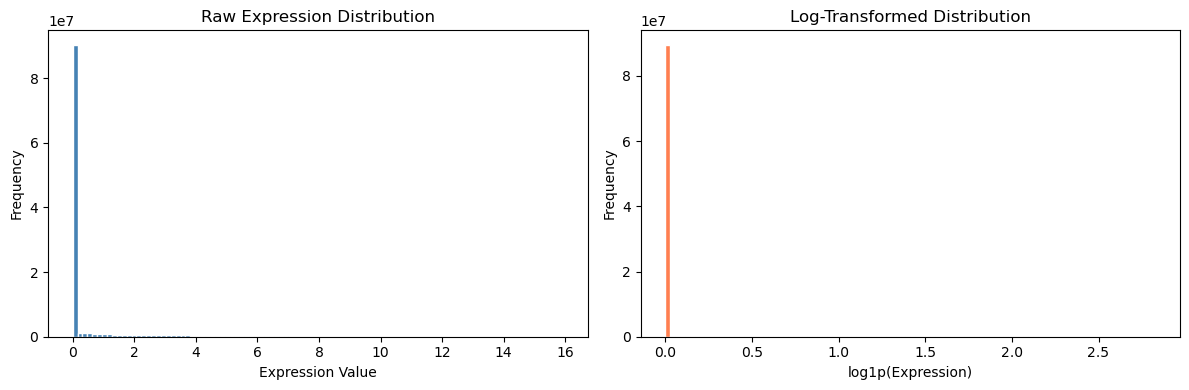

Plot saved!


In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(expr.values.flatten(), bins=100, color='steelblue', edgecolor='white')
plt.title("Raw Expression Distribution")
plt.xlabel("Expression Value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
log_vals = np.log1p(expr.values.flatten())
plt.hist(log_vals, bins=100, color='coral', edgecolor='white')
plt.title("Log-Transformed Distribution")
plt.xlabel("log1p(Expression)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig('../results/01_expression_distribution.png', dpi=150)
plt.show()
print("Plot saved!")

## Analyze gene-wise variance

This cell measures how much each gene varies across samples and visualizes that distribution.

- `expr.var(axis=1)` computes variance across columns for each row.
- `axis=1` is important here: it means we calculate variance across each gene's expression values across samples.
- `gene_variance` stores one variance value per gene.
- `gene_variance.quantile(0.2)` finds the 20th percentile of gene variance.
- `plt.axvline(...)` draws a vertical reference line at that cutoff.

This is useful for identifying low-variance genes, which are often less informative for downstream dimensionality reduction or clustering.


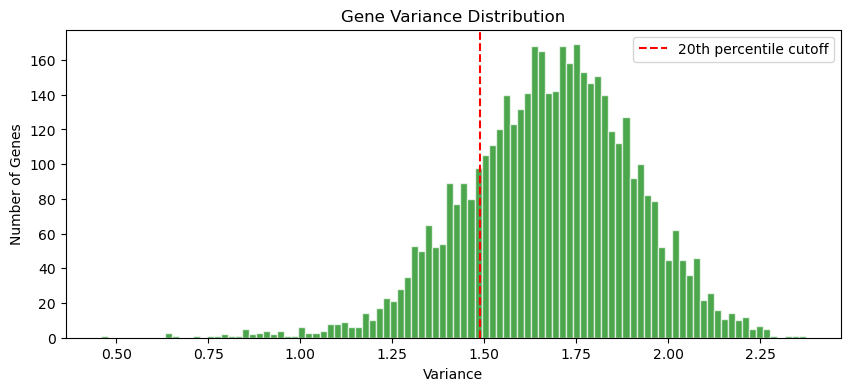

In [14]:
gene_variance = expr.var(axis=1)
plt.figure(figsize=(10, 4))
plt.hist(gene_variance, bins=100, color='green', edgecolor='white', alpha=0.7)
plt.title("Gene Variance Distribution")
plt.xlabel("Variance")
plt.ylabel("Number of Genes")
plt.axvline(gene_variance.quantile(0.2), color='red',
            linestyle='--', label='20th percentile cutoff')
plt.legend()
plt.savefig('../results/02_gene_variance.png', dpi=150)
plt.show()

## Explore metadata categories

This cell inspects the metadata structure and the diversity of values in each metadata row.

- `meta.index.tolist()` prints the row labels so we can see what metadata fields are present.
- The `for row in meta.index:` loop checks each metadata row one by one.
- `meta.loc[row]` selects the full row by label.
- `.nunique()` counts how many distinct values appear in that row.
- `.unique()[:5]` shows the first few unique values as examples.

This helps us understand which metadata fields may be useful later for interpretation, labeling, or cluster comparison.


In [15]:
print("\nMetadata row names:", meta.index.tolist())
print("\nUnique values per row:")
for row in meta.index:
    print(f"  {row}: {meta.loc[row].nunique()} unique values")
    print(f"    Sample values: {meta.loc[row].unique()[:5]}")


Metadata row names: ['Cy72_CD45_H02_S758_comb', 'CY58_1_CD45_B02_S974_comb', 'Cy71_CD45_D08_S524_comb', 'Cy81_FNA_CD45_B01_S301_comb', 'Cy80_II_CD45_B07_S883_comb', 'Cy81_Bulk_CD45_B10_S118_comb', 'Cy72_CD45_D09_S717_comb', 'Cy74_CD45_A03_S387_comb', 'Cy71_CD45_B05_S497_comb', 'Cy80_II_CD45_C09_S897_comb', 'Cy74_CD45_F09_S453_comb', 'CY58_1_CD45_D03_S999_comb', 'Cy72_CD45_C01_S697_comb', 'Cy71_CD45_D07_S523_comb', 'Cy81_FNA_CD45_C12_S228_comb', 'Cy81_FNA_CD45_E05_S341_comb', 'Cy74_CD45_D04_S424_comb', 'Cy74_CD45_C11_S419_comb', 'Cy81_Bulk_CD45_E10_S154_comb', 'Cy80_II_CD45_H07_S955_comb', 'CY58_1_CD45_F01_S1021_comb', 'Cy81_FNA_CD45_D09_S333_comb', 'Cy71_CD45_E12_S540_comb', 'Cy81_FNA_CD45_D07_S235_comb', 'Cy72_CD45_D07_S715_comb', 'Cy72_CD45_E08_S728_comb', 'Cy71_CD45_B07_S499_comb', 'Cy71_CD45_G02_S554_comb', 'Cy71_CD45_E03_S531_comb', 'Cy74_CD45_H03_S471_comb', 'Cy81_Bulk_CD45_B11_S119_comb', 'Cy80_II_CD45_H09_S957_comb', 'Cy72_CD45_E02_S722_comb', 'Cy72_CD45_D03_S711_comb', 'Cy80_